# `quantrisk` Library

In [1]:
from quantrisk import ARMAGARCH, Backtest, Plotter, Risk, Statistics
import numpy as np
import pandas as pd

For this demo we will be analyzing log returns of Apple (AAPL) from 01/02/2015-05/29/2026. We will use the last 1000 trading days in our demo.

In [2]:
path = "DATA/AAPL.csv"
df = pd.read_csv(path, header=[0, 1], index_col=0, parse_dates=True)
prices = df["Close"].dropna()
returns = np.log(prices / prices.shift(1)).dropna()
df["Returns"] = returns
data = df["Returns"].iloc[-1000:]

# 1. ARMA(1,1)-GARCH(1,1)

We will first fit an ARMA(1,1)-GARCH(1,1) model with Gaussian shocks to our returns data. Later (see Sec. 2) we will see how we can model the data using shocks from other distributions. 

We use the following notation:
$$r_t = \mathbb{E}[r_{t}|\mathcal{F}_{t-1}] + \varepsilon_t = \xi + \phi r_{t-1} + \theta \varepsilon_{t-1} + \varepsilon_{t}$$
$$\sigma_{t}^2 = C + B \sigma_{t-1}^2 + A\varepsilon_{t-1}^2$$
$$\varepsilon_t = \sigma_t z_t$$
$$z_t \sim N(0,1)$$
Here $\mathcal{F}_t$ denotes the filtration at time $t$. We refer to $\{\varepsilon_t\}$ as the **innovations** and $\{z_t\}$ as the **shocks**. 

First create an `ARMAGARCH` object and fit the model by using the `.fit()` method.

In [3]:
AAPL_AG = ARMAGARCH()
AAPL_AG.fit(data)

The fitted ARMA and GARCH parameters are stored in a dictionary as instance attributes called `.ARMA_params` and `.GARCH_params`, respectively.

In [24]:
print("Fitted ARMA parameters:")
for parameter, value in AAPL_AG.ARMA_params.items():
    print(f"{parameter} = {value}")

Fitted ARMA parameters:
phi = -0.12531441181056213
theta = 0.1735936554506209
xi = 0.0008376853332238213


In [25]:
print("Fitted GARCH parameters:")
for k,v in AAPL_AG.GARCH_params.items():
    print(f"{k} = {v}")

Fitted GARCH parameters:
A = 0.07036095548848638
B = 0.8927952043244026
C = 1.0765482484116214e-05


Once the model has been fit we can retrieve the innovations $\{\varepsilon_t\}$ and the forecasted variances $\{\sigma_t^2\}$ by calling `.get_innovations()`.

In [6]:
eps_t, sigma2_t = AAPL_AG.get_innovations(data)

We can then use the innovations and the forecasted variances to obtain the shocks $\{z_t\}$ using the `.get_shocks()` method, as well as a one day forecast using the `.one_day_forecast()` method.

In [7]:
z_t = AAPL_AG.get_shocks(eps_t, sigma2_t)
forecasted_mean, forecasted_var = AAPL_AG.one_day_forecast(data)

# 2. Risk

As we have seen, `ARMAGARCH` can be used as a standalone class. However, it is most powerful when used within the `Risk` class, as we now describe. One of the advantages with the `Risk` class is the ability to construct an ARMA(1,1)-GARCH(1,1) model with non-Gaussian errors. 

To begin, create a `Risk` object. One can pass in their desired distribution for the shocks. The currently supported distributions are: 
- Gaussian
- (location-scale) Student-t
- Normal Inverse Gaussian (NIG). 

One can also pass in a previously trained ARMA-GARCH model, but this is not necessary (see `README` file for details). 

For our demo we will use the NIG distribution.

In [8]:
AAPL_risk = Risk(dist = "NIG")

To fit the model, first fit the ARMA(1,1)-GARCH(1,1) model as before.

In [9]:
AAPL_risk.ARMAGARCH.fit(data)

Alternatively, we could have fed in the previously fit ARMA-GARCH model directly into the constructor:

In [10]:
AAPL_risk = Risk(dist = "NIG", ARMAGARCH_model = AAPL_AG)

Then to fit the distribution use `.fit_distribution(data)`

In [11]:
AAPL_risk.fit_distribution(data)

[0.9738810695478767, -0.04293093651227908]

With our distribution and ARMA-GARCH model calibrated, we are prepared to compute risk metrics. We can obtain a one day out of sample VaR and CVaR/Expected Shortfall values by calling `.get_VaR(data, alpha)` and `.get_CVaR(data, alpha)`. 

*Note: Here $\alpha$ is the tail probability, so e.g. 99% VaR would correspond to $\alpha = 0.01$*

In [12]:
VaR = AAPL_risk.get_VaR(data, 0.01)
CVaR = AAPL_risk.get_CVaR(data, 0.01)

# 3. Backtesting

The model can be evaluated by performing a rolling window backtest and then running statistical tests. To do this, begin by creating an instance of the `Backtest` class. In the constructor we pass in our data, the desired VaR level, and the distribution type. In this example we will be using 99% VaR (e.g. $\alpha$ = 0.01) and an NIG distribution.

In [13]:
AAPL_backtest = Backtest(data, 0.01, "NIG")

To perform the rolling window backtest call the `.rolling_window(window_size)` method, where `window_size` is the size of the rolling window. We will use a rolling window of 250 trading days. This will return both the predicted and observed value for each day. 

In [14]:
forecast, observed = AAPL_backtest.rolling_window(250)

/Users/hasibrahimyar/opt/anaconda3/lib/python3.7/site-packages/scipy/stats/_distn_infrastructure.py:1797: RuntimeWarning: divide by zero encountered in log
  return log(self._pdf(x, *args))
/Users/hasibrahimyar/opt/anaconda3/lib/python3.7/site-packages/scipy/optimize/_numdiff.py:557: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


The `.rolling_window` method will also store the forecasted and observed values as object attributes, as well as the CDF values for each out of sample evaluation. They can be accessed as follows:

In [15]:
forecasts = AAPL_backtest.forecasts
observed = AAPL_backtest.observed
CDF_evals = AAPL_backtest.CDF_evals

We can now evaluate our backtest using the `statistical_tests(p_threshold)` method, here `p_threshold` is the significance level for the statistical tests, which by default is set to 0.05. The result is a dictionary where the key is the various test names (Binomial, Kupiec, Christoffersen, Conditional Coverage, and KS) and the value is a tuple whose first entry is the $p$-value and the second entry is a Boolean indicating whether the test was passed or not.

In [27]:
result = AAPL_backtest.statistical_tests(p_threshold = 0.05)
for test, (p_val, passed) in result.items():
    print(f"{test:<25} p-value = {p_val:.4f} | Passed = {passed}")

Binomial                  p-value = 0.9515 | Passed = True
Kupiec                    p-value = 0.8560 | Passed = True
Christoffersen            p-value = 0.6777 | Passed = True
Conditional Coverage      p-value = 0.9023 | Passed = True
KS                        p-value = 0.9020 | Passed = True


# 4. Statistics & Visualization

One can also call the individual tests by calling the respective method in the `Statistics` class. This can be done by instantiating a `Statistics` object with the forecasts, observed values, and desired $\alpha$. For example:

In [17]:
AAPL_stats = Statistics(forecast, observed, 0.01)

Then we can run the invidual tests by calling the corresponding method. In each case the value returned is a tuple containing the test-statistic and the $p$-value 

*Note :* `binomial` *is an exception, and returns the raw number of exceedances.*

*Note 2: Due to the nature of the test, the `KS` method requires the CDF evaluations as an input.*

In [18]:
binomial = AAPL_stats.binomial()
kupiec = AAPL_stats.kupiec()
christoffersen = AAPL_stats.christoffersen()
conditional_coverage = AAPL_stats.conditional_coverage()
KS = AAPL_stats.KS(CDF_evals)

To visualize how our calibrated distribution captures extreme tail events we can construct a QQ plot using the `Plotter` class as follows:

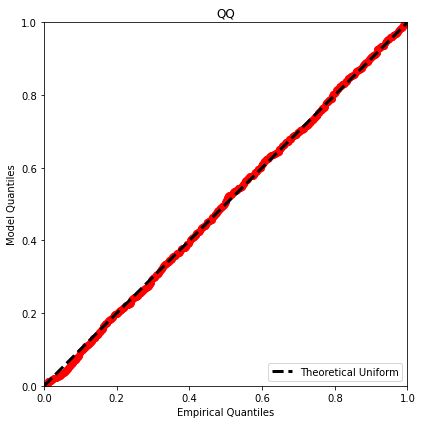

In [20]:
Plotter.QQ(CDF_evals, forecasts, observed, 0.01)

Next, we graph the historical time series with our computed 99% VaR threshold overlaid in red. The exceedeances are marked with a black X, making it easy to audit the model for structural violation clustering.

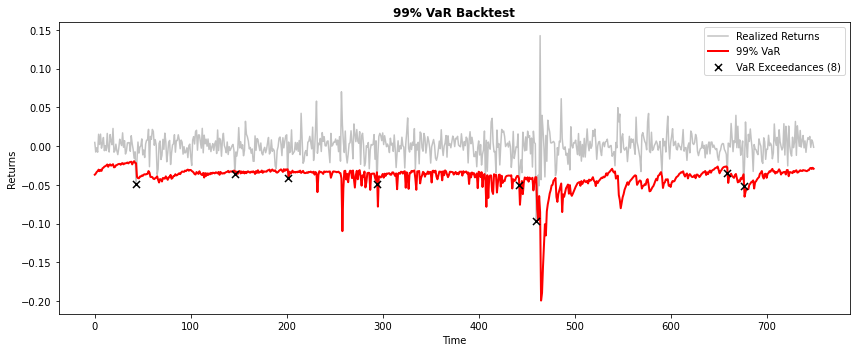

In [22]:
Plotter.VaR(forecasts, observed, 0.01)